All libraries imported successfully!
Configuration:
  Base Path: C:\Users\shivd\Downloads\archive (3)
  Train Path: C:\Users\shivd\Downloads\archive (3)\train
  Test Path: C:\Users\shivd\Downloads\archive (3)\test
  Output Train CSV: C:\Users\shivd\Downloads\train_landmarks.csv
  Output Test CSV: C:\Users\shivd\Downloads\test_landmarks.csv
  Selected Emotions: ['angry', 'happy', 'sad', 'neutral']

VERIFYING DATASET STRUCTURE
Base path found: C:\Users\shivd\Downloads\archive (3)

TRAIN folder:
        angry:  3995 images
      disgust:   436 images
         fear:  4097 images
        happy:  7215 images
      neutral:  4965 images
          sad:  4830 images
     surprise:  3171 images

TEST folder:
        angry:   958 images
      disgust:   111 images
         fear:  1024 images
        happy:  1774 images
      neutral:  1233 images
          sad:  1247 images
     surprise:   831 images

Dataset structure verified!

INITIALIZING MEDIAPIPE
MediaPipe Face Mesh initialized!
Note: With

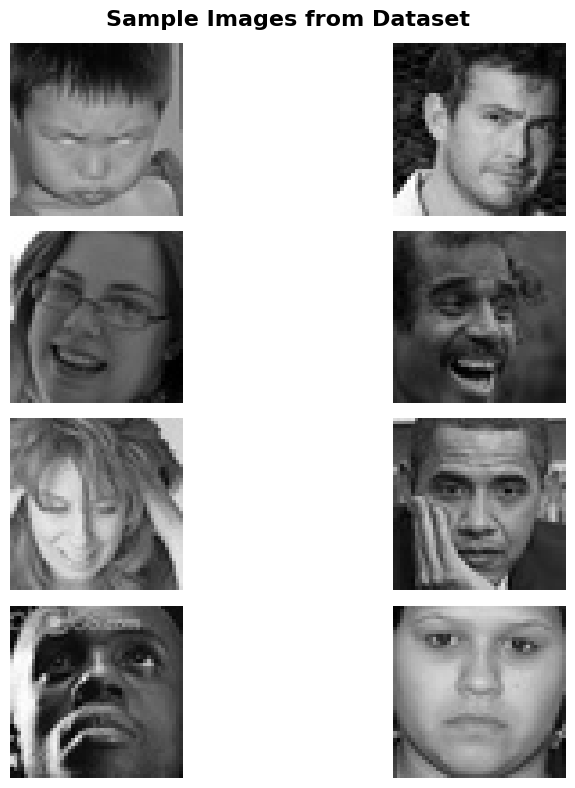


Testing landmark detection on sample image:
Visualizing: angry/Training_10118481.jpg


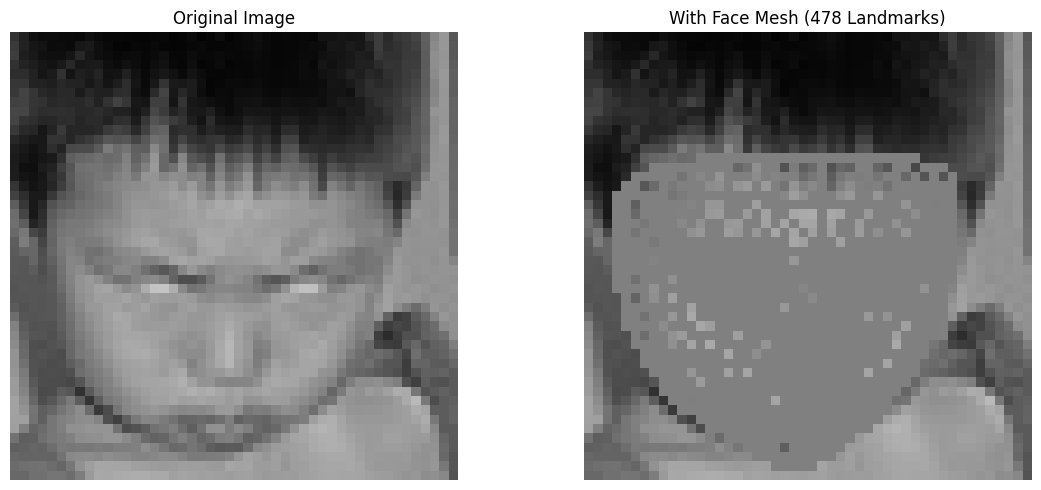


STEP 1: PROCESSING TRAINING SET

EXTRACTING LANDMARKS FROM TRAINING SET

Base path: C:\Users\shivd\Downloads\archive (3)\train

Processing 'angry' (3995 images)


  Angry     :   0%|          | 0/3995 [00:00<?, ?it/s]


Processing 'happy' (7215 images)


  Happy     :   0%|          | 0/7215 [00:00<?, ?it/s]


Processing 'sad' (4830 images)


...


Processing 'sad' (1247 images)


  Sad       :   0%|          | 0/1247 [00:00<?, ?it/s]


Processing 'neutral' (1233 images)


  Neutral   :   0%|          | 0/1233 [00:00<?, ?it/s]


Successfully processed: 4859 images
Skipped (no face detected): 353 images
Success rate: 93.23%
Detected 478 landmarks per image (956 features)

Saved landmarks to: C:\Users\shivd\Downloads\test_landmarks.csv
Dataset shape: (4859, 957)

TRAINING SET ANALYSIS

Total samples: 19633
Number of features: 956

Emotion Distribution:
----------------------------------------
     Angry:  3555 samples (18.11%)
     Happy:  6948 samples (35.39%)
       Sad:  4321 samples (22.01%)
   Neutral:  4809 samples (24.49%)

First few rows of landmark data:
   landmark_0_x  landmark_0_y  landmark_1_x  landmark_1_y  landmark_2_x  \
0      0.474692      0.843659      0.528942      0.807010      0.512449   
1      0.692346      0.740956      0.754652      0.666554      0.727026   
2      0.682535      0.450173      0.690665      0.355089      0.656798   
3      0.518341      0.601757      0.488840      0.453064      0.498986   
4      0.471739      0.748859      0.448831      0.635072      0.462873   

   la

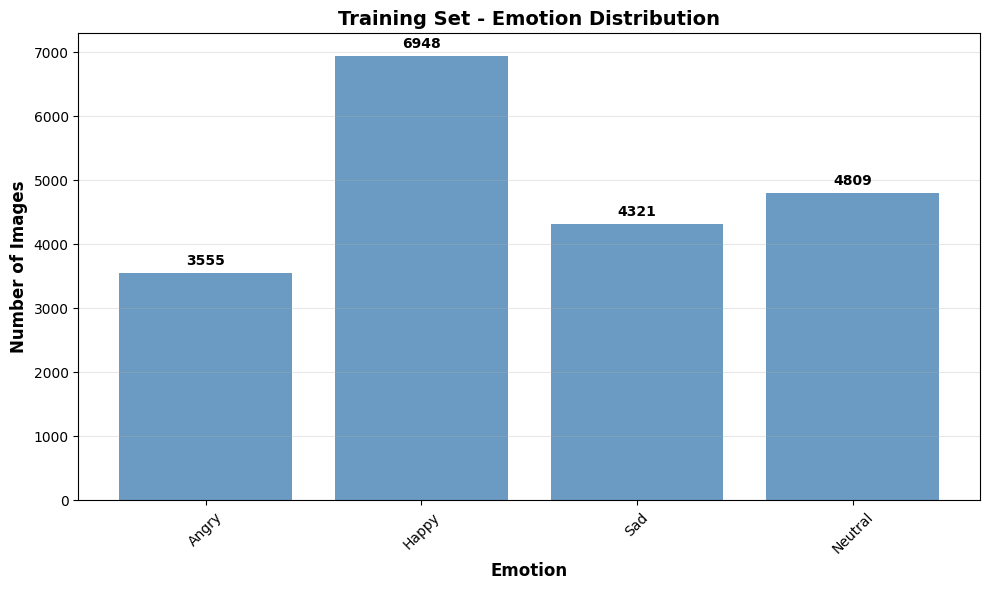

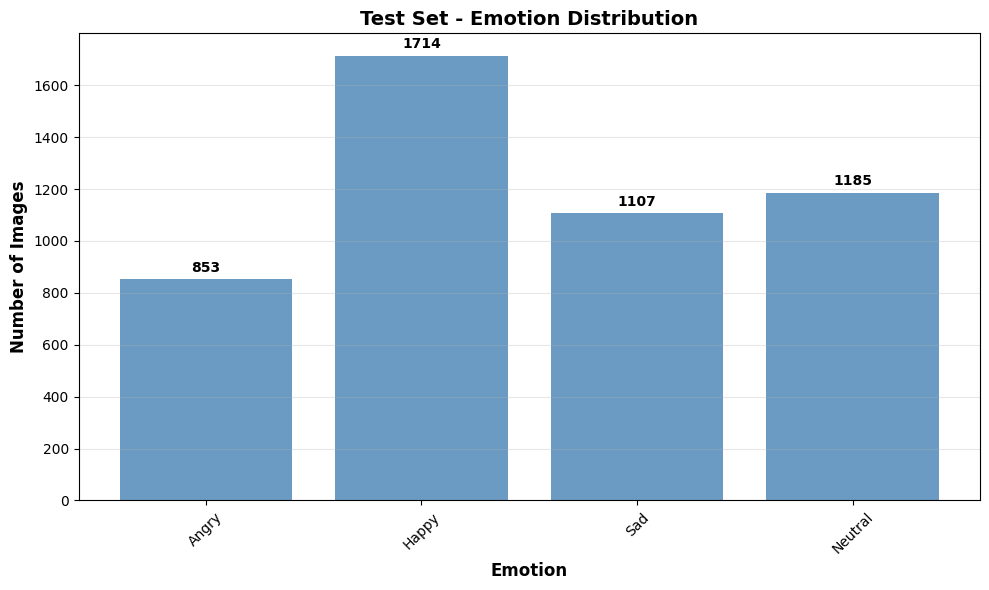


TRAIN VS TEST COMPARISON

Emotion      Train      Test       Ratio     
--------------------------------------------------
Angry        3555       853        4.17      
Happy        6948       1714       4.05      
Sad          4321       1107       3.90      
Neutral      4809       1185       4.06      
--------------------------------------------------
TOTAL        19633      4859      

PIPELINE COMPLETE!

TRAINING SET:
  Output: C:\Users\shivd\Downloads\train_landmarks.csv
  Samples: 19633
  Landmarks: 478
  Features: 956 (478 landmarks x 2 coordinates)
  Emotions: 4

TEST SET:
  Output: C:\Users\shivd\Downloads\test_landmarks.csv
  Samples: 4859
  Landmarks: 478
  Features: 956 (478 landmarks x 2 coordinates)
  Emotions: 4

Next Steps:
  1. Use train_landmarks.csv to train your model
  2. Use test_landmarks.csv to evaluate performance
  3. Landmarks are normalized (0-1 range)
  4. Ready for CNN training!


In [4]:
# %% [markdown]
# # Complete FER2013 to Landmark Dataset Pipeline
# ## Process Train/Test Folders → Extract Landmarks → Create Dataset

# %% [markdown]
# ### 1. Install Required Packages

# %%
# !pip install mediapipe opencv-python numpy pandas tqdm

# %% [markdown]
# ### 2. Import Libraries

# %%
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

# %% [markdown]
# ### 3. Configuration - SET YOUR PATHS HERE

# %%
# CONFIGURE PATHS
BASE_PATH = r"C:\Users\shivd\Downloads\archive (3)"  # Base folder containing train/test
TRAIN_PATH = os.path.join(BASE_PATH, "train")  # Train folder with emotion subfolders
TEST_PATH = os.path.join(BASE_PATH, "test")    # Test folder with emotion subfolders

OUTPUT_TRAIN_CSV = r"C:\Users\shivd\Downloads\train_landmarks.csv"  # Training landmarks
OUTPUT_TEST_CSV = r"C:\Users\shivd\Downloads\test_landmarks.csv"    # Test landmarks

# Emotion mapping
EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}

# We'll focus on these 4 emotions (you can change this)
SELECTED_EMOTIONS = ['angry', 'happy', 'sad', 'neutral']

print("Configuration:")
print(f"  Base Path: {BASE_PATH}")
print(f"  Train Path: {TRAIN_PATH}")
print(f"  Test Path: {TEST_PATH}")
print(f"  Output Train CSV: {OUTPUT_TRAIN_CSV}")
print(f"  Output Test CSV: {OUTPUT_TEST_CSV}")
print(f"  Selected Emotions: {SELECTED_EMOTIONS}")

# %% [markdown]
# ### 4. Verify Dataset Structure

# %%
def verify_dataset_structure(base_path):
    """Verify and display dataset structure"""
    print("\n" + "="*60)
    print("VERIFYING DATASET STRUCTURE")
    print("="*60)
    
    if not os.path.exists(base_path):
        print(f"Base path not found: {base_path}")
        return False
    
    print(f"Base path found: {base_path}\n")
    
    # Check train folder
    train_path = os.path.join(base_path, "train")
    if os.path.exists(train_path):
        print("TRAIN folder:")
        for emotion in os.listdir(train_path):
            emotion_path = os.path.join(train_path, emotion)
            if os.path.isdir(emotion_path):
                count = len([f for f in os.listdir(emotion_path) 
                           if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
                print(f"   {emotion:>10}: {count:>5} images")
    else:
        print("Train folder not found")
        return False
    
    # Check test folder
    test_path = os.path.join(base_path, "test")
    if os.path.exists(test_path):
        print("\nTEST folder:")
        for emotion in os.listdir(test_path):
            emotion_path = os.path.join(test_path, emotion)
            if os.path.isdir(emotion_path):
                count = len([f for f in os.listdir(emotion_path) 
                           if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
                print(f"   {emotion:>10}: {count:>5} images")
    else:
        print("Test folder not found (optional)")
    
    print("\n" + "="*60)
    return True

# Verify structure
if verify_dataset_structure(BASE_PATH):
    print("Dataset structure verified!")
else:
    print("Please check your dataset path")

# %% [markdown]
# ### 5. Initialize MediaPipe Face Mesh

# %%
print("\n" + "="*60)
print("INITIALIZING MEDIAPIPE")
print("="*60)

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

print("MediaPipe Face Mesh initialized!")
print("Note: With refine_landmarks=True, 478 landmarks will be extracted (includes iris)")

# %% [markdown]
# ### 6. Visualize Sample Images

# %%
def visualize_sample_images(base_path, emotions, samples_per_emotion=2):
    """Display sample images from each emotion"""
    fig, axes = plt.subplots(len(emotions), samples_per_emotion, figsize=(10, 8))
    fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
    
    for i, emotion in enumerate(emotions):
        emotion_path = os.path.join(base_path, emotion)
        if not os.path.exists(emotion_path):
            continue
            
        image_files = [f for f in os.listdir(emotion_path) 
                      if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:samples_per_emotion]
        
        for j, img_file in enumerate(image_files):
            img_path = os.path.join(emotion_path, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                # Convert BGR to RGB
                if len(img.shape) == 3:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                ax = axes[i, j] if samples_per_emotion > 1 else axes[i]
                ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
                ax.axis('off')
                if j == 0:
                    ax.set_ylabel(emotion.capitalize(), fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Visualize samples from train folder
if os.path.exists(TRAIN_PATH):
    print("\nSample images from training set:")
    visualize_sample_images(TRAIN_PATH, SELECTED_EMOTIONS)

# %% [markdown]
# ### 7. Landmark Extraction Functions

# %%
def extract_landmarks(image_path):
    """
    Extract facial landmarks from an image using MediaPipe
    Returns flattened array of (x, y) coordinates
    Note: With refine_landmarks=True, MediaPipe returns 478 landmarks (956 features)
    """
    try:
        # Read image
        image = cv2.imread(image_path)
        
        if image is None:
            return None
        
        # Convert to RGB
        if len(image.shape) == 2:  # Grayscale
            image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Process image
        results = face_mesh.process(image_rgb)
        
        # Extract landmarks
        if results.multi_face_landmarks:
            landmarks = results.multi_face_landmarks[0]
            
            # Extract x, y coordinates (478 landmarks with refine_landmarks=True)
            coords = []
            for landmark in landmarks.landmark:
                coords.append(landmark.x)
                coords.append(landmark.y)
            
            return np.array(coords)
        else:
            return None
    except Exception as e:
        return None

def visualize_landmarks(image_path):
    """Visualize an image with detected landmarks"""
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return
    
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to read image: {image_path}")
        return
    
    # Convert to RGB
    if len(image.shape) == 2:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        display_img = image
    else:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        display_img = image_rgb
    
    results = face_mesh.process(image_rgb)
    
    if results.multi_face_landmarks:
        annotated_image = image_rgb.copy()
        for face_landmarks in results.multi_face_landmarks:
            mp_drawing.draw_landmarks(
                image=annotated_image,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style())
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(display_img, cmap='gray' if len(image.shape) == 2 else None)
        plt.title("Original Image")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(annotated_image)
        plt.title("With Face Mesh (478 Landmarks)")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No face detected!")

# Test visualization on a sample
print("\nTesting landmark detection on sample image:")
if os.path.exists(TRAIN_PATH):
    for emotion in SELECTED_EMOTIONS:
        emotion_path = os.path.join(TRAIN_PATH, emotion)
        if os.path.exists(emotion_path):
            sample_files = [f for f in os.listdir(emotion_path) 
                          if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            if sample_files:
                sample_path = os.path.join(emotion_path, sample_files[0])
                print(f"Visualizing: {emotion}/{sample_files[0]}")
                visualize_landmarks(sample_path)
                break

# %% [markdown]
# ### 8. Process Dataset Function

# %%
def process_dataset(base_path, output_csv, emotions, dataset_name="Dataset"):
    """
    Process entire dataset and extract landmarks
    """
    print("\n" + "="*60)
    print(f"EXTRACTING LANDMARKS FROM {dataset_name.upper()}")
    print("="*60)
    
    if not os.path.exists(base_path):
        print(f"Path not found: {base_path}")
        return None
    
    data = []
    skipped = 0
    
    print(f"\nBase path: {os.path.abspath(base_path)}")
    
    for emotion in emotions:
        emotion_path = os.path.join(base_path, emotion)
        
        if not os.path.exists(emotion_path):
            print(f"Warning: {emotion_path} does not exist. Skipping...")
            continue
        
        # Get all images
        image_files = [f for f in os.listdir(emotion_path) 
                      if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        if len(image_files) == 0:
            print(f"Warning: No images found in {emotion_path}")
            continue
        
        print(f"\nProcessing '{emotion}' ({len(image_files)} images)")
        
        for img_file in tqdm(image_files, desc=f"  {emotion.capitalize():<10}"):
            img_path = os.path.join(emotion_path, img_file)
            
            # Extract landmarks
            landmarks = extract_landmarks(img_path)
            
            if landmarks is not None:
                row = landmarks.tolist() + [EMOTION_MAP[emotion]]
                data.append(row)
            else:
                skipped += 1
    
    print("\n" + "="*60)
    
    total_processed = len(data) + skipped
    
    if total_processed == 0:
        print(f"No images were found in {base_path}")
        return None
    
    print(f"Successfully processed: {len(data)} images")
    print(f"Skipped (no face detected): {skipped} images")
    
    if len(data) > 0:
        print(f"Success rate: {len(data)/total_processed*100:.2f}%")
    else:
        print("No faces were detected in any images!")
        return None
    
    # Create column names dynamically based on actual data
    num_landmarks = len(data[0]) - 1  # Subtract 1 for emotion label
    num_landmark_points = num_landmarks // 2  # Divide by 2 since we have x,y pairs
    
    columns = []
    for i in range(num_landmark_points):
        columns.append(f'landmark_{i}_x')
        columns.append(f'landmark_{i}_y')
    columns.append('emotion')
    
    print(f"Detected {num_landmark_points} landmarks per image ({num_landmarks} features)")
    
    # Create DataFrame
    df = pd.DataFrame(data, columns=columns)
    
    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"\nSaved landmarks to: {output_csv}")
    print(f"Dataset shape: {df.shape}")
    
    return df

# %% [markdown]
# ### 9. Process Training Set

# %%
print("\n" + "="*60)
print("STEP 1: PROCESSING TRAINING SET")
print("="*60)

if os.path.exists(TRAIN_PATH):
    train_df = process_dataset(TRAIN_PATH, OUTPUT_TRAIN_CSV, SELECTED_EMOTIONS, "Training Set")
else:
    print(f"Training path not found: {TRAIN_PATH}")
    train_df = None

# %% [markdown]
# ### 10. Process Test Set

# %%
print("\n" + "="*60)
print("STEP 2: PROCESSING TEST SET")
print("="*60)

if os.path.exists(TEST_PATH):
    test_df = process_dataset(TEST_PATH, OUTPUT_TEST_CSV, SELECTED_EMOTIONS, "Test Set")
else:
    print(f"Test path not found: {TEST_PATH}")
    print("Skipping test set processing")
    test_df = None

# %% [markdown]
# ### 11. Analyze Training Results

# %%
if train_df is not None:
    print("\n" + "="*60)
    print("TRAINING SET ANALYSIS")
    print("="*60)
    
    print(f"\nTotal samples: {len(train_df)}")
    print(f"Number of features: {len(train_df.columns) - 1}")
    
    # Emotion distribution
    emotion_counts = train_df['emotion'].value_counts().sort_index()
    
    emotion_name_map = {v: k.capitalize() for k, v in EMOTION_MAP.items()}
    
    print("\nEmotion Distribution:")
    print("-" * 40)
    for emotion_code, count in emotion_counts.items():
        emotion_name = emotion_name_map.get(emotion_code, f"Unknown ({emotion_code})")
        percentage = (count / len(train_df)) * 100
        print(f"{emotion_name:>10}: {count:>5} samples ({percentage:>5.2f}%)")
    
    # Show first few rows
    print("\nFirst few rows of landmark data:")
    print(train_df.head())

# %% [markdown]
# ### 12. Analyze Test Results

# %%
if test_df is not None:
    print("\n" + "="*60)
    print("TEST SET ANALYSIS")
    print("="*60)
    
    print(f"\nTotal samples: {len(test_df)}")
    print(f"Number of features: {len(test_df.columns) - 1}")
    
    # Emotion distribution
    emotion_counts = test_df['emotion'].value_counts().sort_index()
    
    emotion_name_map = {v: k.capitalize() for k, v in EMOTION_MAP.items()}
    
    print("\nEmotion Distribution:")
    print("-" * 40)
    for emotion_code, count in emotion_counts.items():
        emotion_name = emotion_name_map.get(emotion_code, f"Unknown ({emotion_code})")
        percentage = (count / len(test_df)) * 100
        print(f"{emotion_name:>10}: {count:>5} samples ({percentage:>5.2f}%)")

# %% [markdown]
# ### 13. Visualize Emotion Distributions

# %%
def plot_emotion_distribution(df, title):
    """Plot emotion distribution"""
    emotion_counts = df['emotion'].value_counts().sort_index()
    emotion_name_map = {v: k.capitalize() for k, v in EMOTION_MAP.items()}
    
    plt.figure(figsize=(10, 6))
    emotion_labels = [emotion_name_map[i] for i in emotion_counts.index]
    plt.bar(emotion_labels, emotion_counts.values, color='steelblue', alpha=0.8)
    plt.xlabel('Emotion', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels
    for i, v in enumerate(emotion_counts.values):
        plt.text(i, v + max(emotion_counts.values)*0.01, str(v), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot distributions
if train_df is not None:
    plot_emotion_distribution(train_df, 'Training Set - Emotion Distribution')

if test_df is not None:
    plot_emotion_distribution(test_df, 'Test Set - Emotion Distribution')

# %% [markdown]
# ### 14. Compare Train vs Test

# %%
if train_df is not None and test_df is not None:
    print("\n" + "="*60)
    print("TRAIN VS TEST COMPARISON")
    print("="*60)
    
    emotion_name_map = {v: k.capitalize() for k, v in EMOTION_MAP.items()}
    
    train_counts = train_df['emotion'].value_counts().sort_index()
    test_counts = test_df['emotion'].value_counts().sort_index()
    
    print(f"\n{'Emotion':<12} {'Train':<10} {'Test':<10} {'Ratio':<10}")
    print("-" * 50)
    
    for emotion_code in sorted(train_counts.index):
        emotion_name = emotion_name_map[emotion_code]
        train_count = train_counts.get(emotion_code, 0)
        test_count = test_counts.get(emotion_code, 0)
        ratio = f"{train_count/test_count:.2f}" if test_count > 0 else "N/A"
        print(f"{emotion_name:<12} {train_count:<10} {test_count:<10} {ratio:<10}")
    
    print("-" * 50)
    print(f"{'TOTAL':<12} {len(train_df):<10} {len(test_df):<10}")

# %% [markdown]
# ### 15. Final Summary

# %%
print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)

if train_df is not None:
    num_features = len(train_df.columns) - 1
    num_landmarks = num_features // 2
    print(f"\nTRAINING SET:")
    print(f"  Output: {OUTPUT_TRAIN_CSV}")
    print(f"  Samples: {len(train_df)}")
    print(f"  Landmarks: {num_landmarks}")
    print(f"  Features: {num_features} ({num_landmarks} landmarks x 2 coordinates)")
    print(f"  Emotions: {len(train_df['emotion'].unique())}")

if test_df is not None:
    num_features = len(test_df.columns) - 1
    num_landmarks = num_features // 2
    print(f"\nTEST SET:")
    print(f"  Output: {OUTPUT_TEST_CSV}")
    print(f"  Samples: {len(test_df)}")
    print(f"  Landmarks: {num_landmarks}")
    print(f"  Features: {num_features} ({num_landmarks} landmarks x 2 coordinates)")
    print(f"  Emotions: {len(test_df['emotion'].unique())}")

print("\nNext Steps:")
print("  1. Use train_landmarks.csv to train your model")
print("  2. Use test_landmarks.csv to evaluate performance")
print("  3. Landmarks are normalized (0-1 range)")
print("  4. Ready for CNN training!")
print("="*60)

# %% [markdown]
# ---
# ## Your Landmark Datasets are Ready!
# - **Training**: `train_landmarks.csv`
# - **Testing**: `test_landmarks.csv`